## NGDS-Projekt - Gruppe H

Namen und E-Mail-Adressen der Gruppenmitglieder:

- Melchior von Weissenfluh vonwemel@students.zhaw.ch
- Nico Schellhaas schnic05@students.zhaw.ch

Zugeteilte Wetterstation:  **SMM – Sta. Maria, Val Müstair** (1386 m ü. M.)

### Bibliotheken importieren und globale Parameter definieren

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy import optimize
from scipy.optimize import fsolve
from scipy.optimize import newton

### 1. Daten importieren und filtern

Importiert die Daten (Strings und Zahlen getrennt), wählt die relevanten Spalten und Zeilen aus. Am Ende sollt ihr je ein Array für den Messzeitpunkt (in Tagen seit der ersten Messung, nicht als Datetime Objekte) und die gemessenen Wetterdaten für eure Wetterstation haben.

In [2]:
# Strings laden (Station + Datum)
strings = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", dtype=str, skip_header=1)

# Numerische Daten laden
numbers = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", skip_header=1)

# Zeit in Tagen
time_array = numbers[:, 6]
# Wetterdaten
weather_array = numbers[:, 2:6]
# Station auswählen
station_mask = strings[:, 0] == "SMM"
time_array = time_array[station_mask]
weather_array = weather_array[station_mask]

# Test Form
print(time_array.shape)
print(weather_array.shape)


(7384,)
(7384, 4)


### 2. Interpolation

Wir haben 15% der Zeilen in den Originaldaten gelöscht. Also gibt es nicht genau stündlich Messwerte.

Bestimmt eine Interpolationsfunktion für jede Messgrösse und interpoliert die Messreihen viertelstündlich (d.h. für jede Stunde vier Werte plus den Endpunkt am 1. Januar um 0:00).

Wählt die Art und den Grad der Interpolation so aus, dass die interpolierten Werte auch physikalisch sinnvoll sind.

In [3]:
# 1. Spalten aus deinem weather_array extrahieren
# WICHTIG: Prüfe in der 'Legende' der CSV, ob die Reihenfolge stimmt!
luftdruck = weather_array[:, 0]
temperatur = weather_array[:, 1]
regen = weather_array[:, 2]
sonne = weather_array[:, 3]

# 2. Ziel-Zeitachse definieren (Viertelstündlich)
# Wir nutzen dein 'time_array'
t_interp = np.arange(0, time_array[-1], 1/(24*4))
t_interp = np.append(t_interp, time_array[-1]) # Endpunkt hinzufügen

# 3. Interpolationsfunktionen erstellen
# Kubisch für glatte Verläufe, Linear für Regen/Sonne (wegen physikalischer Sinnhaftigkeit)
f_temp = interp1d(time_array, temperatur, kind='cubic')
f_druck = interp1d(time_array, luftdruck, kind='cubic')
f_regen = interp1d(time_array, regen, kind='linear')
f_sonne = interp1d(time_array, sonne, kind='linear')

# 4. Neue Werte berechnen
temp_interp = f_temp(t_interp)
druck_interp = f_druck(t_interp)
regen_interp = f_regen(t_interp)
sonne_interp = f_sonne(t_interp)

### 3. Daten und Interpolation darstellen und vergleichen 

Um die Interpolation zu überprüfen, stellt für alle Variablen jeweils die Daten und die Interpolationsfunktion zusammen grafisch dar.

Wählt dazu ein Zeitfenster von ein paar Tagen, in dem alle Variablen ein etwas interessantes Verhalten zeigen, d.h. es fällt Regen und die Sonne scheint.

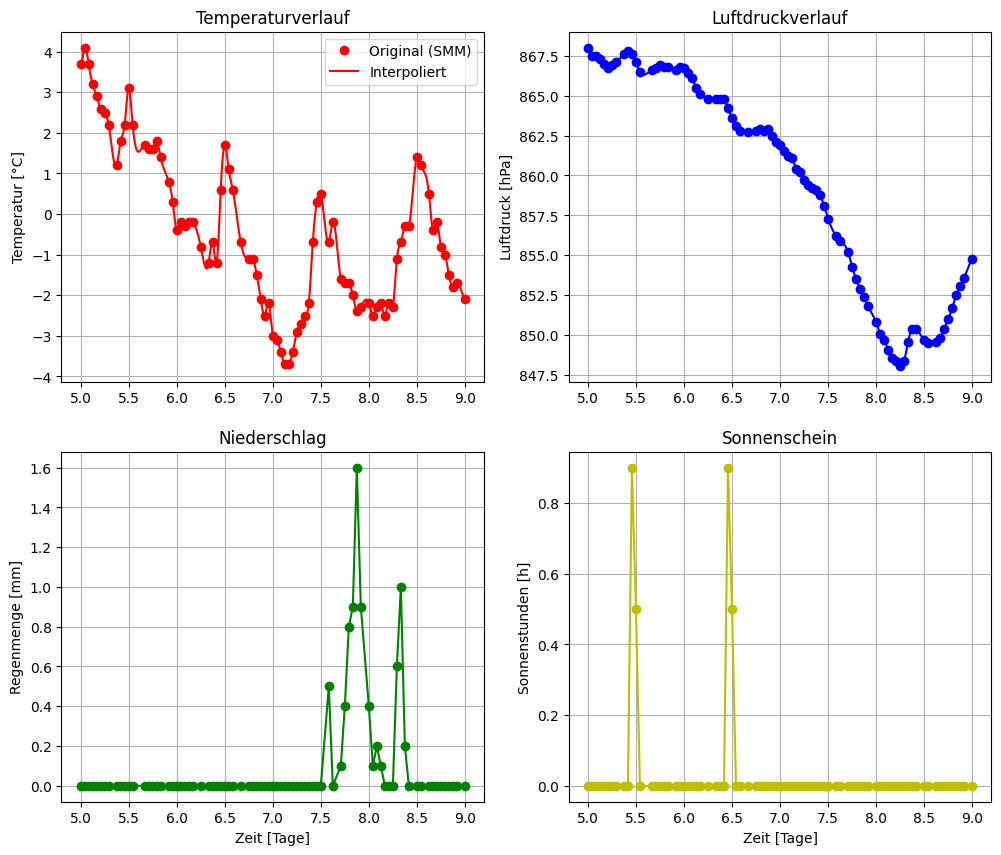

In [4]:
# Zeitfenster wählen (z.B. 3 Tage in der Mitte des Jahres) 5, 9
t_start, t_end = 5, 9 

# Masken erstellen, um nur diesen Zeitraum zu plotten
m_orig = (time_array >= t_start) & (time_array <= t_end)
m_new = (t_interp >= t_start) & (t_interp <= t_end)

# Layout erstellen: 2 Zeilen, 2 Spalten
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1. Temperatur Plot (Oben Links -> Zeile 0, Spalte 0)
axs[0, 0].plot(time_array[m_orig], temperatur[m_orig], 'ro', label='Original (SMM)')
axs[0, 0].plot(t_interp[m_new], temp_interp[m_new], 'r-', label='Interpoliert')
axs[0, 0].set_ylabel('Temperatur [°C]')
axs[0, 0].set_title('Temperaturverlauf')
axs[0, 0].legend()
axs[0, 0].grid()


# 2. Luftdruck Plot (Oben Rechts -> Zeile 0, Spalte 1)
axs[0, 1].plot(time_array[m_orig], luftdruck[m_orig], 'bo')
axs[0, 1].plot(t_interp[m_new], druck_interp[m_new], 'b-')
axs[0, 1].set_ylabel('Luftdruck [hPa]')
axs[0, 1].set_title('Luftdruckverlauf')
axs[0, 1].grid()


# 3. Regen Plot (Unten Links -> Zeile 1, Spalte 0)
axs[1, 0].plot(time_array[m_orig], regen[m_orig], 'go')
axs[1, 0].plot(t_interp[m_new], regen_interp[m_new], 'g-')
axs[1, 0].set_ylabel('Regenmenge [mm]')
axs[1, 0].set_xlabel('Zeit [Tage]')
axs[1, 0].set_title('Niederschlag')
axs[1, 0].grid()


# 4. Sonne Plot (Unten Rechts -> Zeile 1, Spalte 1)
axs[1, 1].plot(time_array[m_orig], sonne[m_orig], 'yo')
axs[1, 1].plot(t_interp[m_new], sonne_interp[m_new], 'y-')
axs[1, 1].set_ylabel('Sonnenstunden [h]')
axs[1, 1].set_xlabel('Zeit [Tage]')
axs[1, 1].set_title('Sonnenschein')
axs[1, 1].grid()


# Verhindert, dass sich Titel und Achsenbeschriftungen überschneiden


plt.show()

### 4. Nullstellen der Temperatur bestimmen

Wählt einen Zeitraum von ca. einer Woche, in der die Temperatur um Null herum schwankt. 

Bestimmt die Zeitpunkte, an denen die Temperatur den Wert Null hat. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die Temperatur und die Nullstellen zusammen grafisch dar.

Alternativ (und ein wenig schwieriger) könnt ihr auch einen Zeitraum wählen, in der die Temperatur hohe Werte erreicht. Bestimmt dann die Zeitpunkte, an denen die Temperatur einen bestimmten Hitzewert überschreitet, z.B. 30 Grad.

#### Warum das Newton-Verfahren?

Um die genauen Zeitpunkte zu finden, an denen die Temperatur den Wert 0 °C überschreitet, benötigen wir ein numerisches Nullstellenverfahren. Wir verwenden dafür das **Newton-Verfahren** (auch Newton-Raphson-Verfahren genannt).

---

**Grundidee**

Das Newton-Verfahren sucht iterativ nach einem Punkt $t^*$, an dem $f(t^*) = 0$ gilt. Startend von einem Anfangswert $t_0$ (nahe der gesuchten Nullstelle) wird die Funktion durch ihre Tangente angenähert und der Schnittpunkt der Tangente mit der $t$-Achse als nächster Näherungswert verwendet:

$$t_{n+1} = t_n - \frac{f(t_n)}{f'(t_n)}$$

Dieser Schritt wird wiederholt, bis die Änderung $|t_{n+1} - t_n|$ kleiner als eine festgelegte Toleranz ist.

---

**Warum Newton und nicht etwas anderes?**

| Methode | Konvergenz | Voraussetzung | Nachteil |
|---|---|---|---|
| Bisektion | linear | Vorzeichenwechsel bekannt | Langsam |
| Sekanten-Verfahren | superlinear | 2 Startwerte | Weniger stabil |
| **Newton-Verfahren** | **quadratisch** | **Ableitung vorhanden** | **Startwert muss nahe der Nullstelle sein** |

Das Newton-Verfahren konvergiert **quadratisch** — das bedeutet, dass sich die Anzahl der korrekten Dezimalstellen mit jedem Schritt ungefähr verdoppelt. Es ist damit deutlich schneller als z.B. die Bisektion.

---

**Warum passt es hier?**

Unsere Interpolationsfunktion `f_temp` ist eine **glatte, differenzierbare Kurve** (kubische Spline-Interpolation). Das Newton-Verfahren setzt genau das voraus, da es intern die Ableitung der Funktion berechnet. Die nötigen Startwerte gewinnen wir durch eine einfache Vorzeichenwechsel-Suche auf dem interpolierten Datengitter — damit starten wir immer nahe an der echten Nullstelle und das Verfahren konvergiert zuverlässig.

In `scipy.optimize.newton` wird die Ableitung automatisch numerisch approximiert, falls sie nicht explizit angegeben wird.

In [13]:


# Zeitraum in dem nach Nullstellen gesucht wird (ca. eine Woche mit Temperaturschwankungen um 0°C)
t_start_null = 1
t_end_null = 10

# Maske für diesen Zeitraum erstellen
mask_null = (t_interp >= t_start_null) & (t_interp <= t_end_null)
t_woche = t_interp[mask_null]
temp_woche = temp_interp[mask_null]

# 1. Grobe Stellen finden, wo die Kurve die Nulllinie kreuzt (Vorzeichenwechsel)
vorzeichenwechsel = np.where(np.diff(np.sign(temp_woche)))[0]
grobe_nullstellen = t_woche[vorzeichenwechsel]

# 2. Exakte Nullstellen mit dem Newton-Verfahren bestimmen
exakte_nullstellen = []

for start_wert in grobe_nullstellen:
    try:
        root = newton(f_temp, start_wert)
        # Nur gültige Wurzeln im gesuchten Zeitraum, ohne Duplikate
        if t_start_null <= root <= t_end_null:
            if len(exakte_nullstellen) == 0 or not np.isclose(root, exakte_nullstellen[-1]):
                exakte_nullstellen.append(root)
    except RuntimeError:
        continue

exakte_nullstellen = np.array(exakte_nullstellen)

print(f"Gefundene Nullstellen (Newton-Verfahren) zwischen Tag {t_start_null} und Tag {t_end_null}:")
for i, ns in enumerate(exakte_nullstellen, 1):
    print(f"  Nullstelle {i}: Tag {ns:.4f}")


Gefundene Nullstellen (Newton-Verfahren) zwischen Tag 1 und Tag 10:
  Nullstelle 1: Tag 3.3233
  Nullstelle 2: Tag 3.3333
  Nullstelle 3: Tag 3.4008
  Nullstelle 4: Tag 3.4220
  Nullstelle 5: Tag 5.9733
  Nullstelle 6: Tag 6.4468
  Nullstelle 7: Tag 6.6224
  Nullstelle 8: Tag 7.4416
  Nullstelle 9: Tag 7.5306
  Nullstelle 10: Tag 8.4360
  Nullstelle 11: Tag 8.6445
  Nullstelle 12: Tag 9.5083
  Nullstelle 13: Tag 9.5502


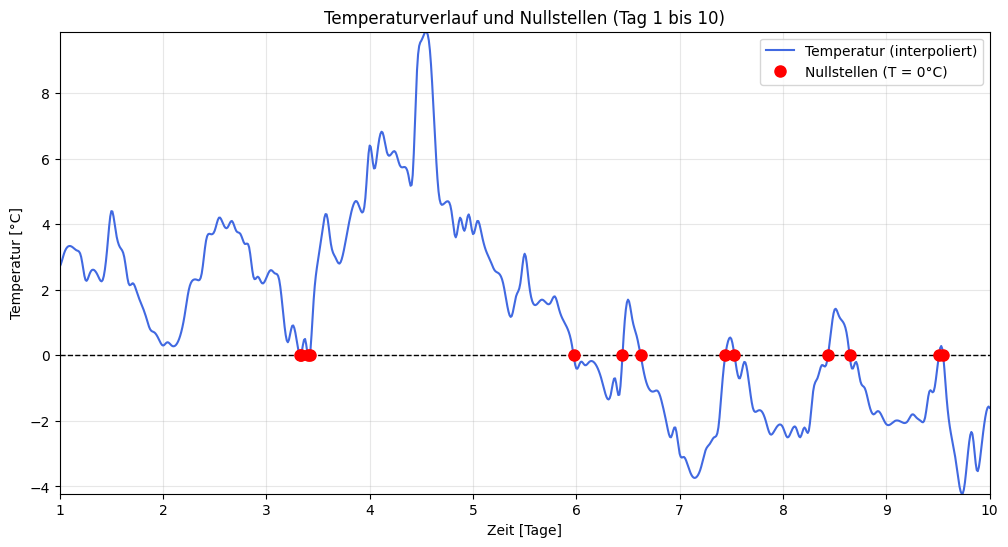

In [14]:
plt.figure(figsize=(12, 6))

# Temperaturverlauf
plt.plot(t_woche, temp_woche, color='royalblue', label='Temperatur (interpoliert)')

# Nulllinie
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Nullstellen als rote Punkte markieren
plt.plot(exakte_nullstellen, np.zeros_like(exakte_nullstellen), 'ro',
         markersize=8, label='Nullstellen (T = 0°C)')

plt.title(f'Temperaturverlauf und Nullstellen (Tag {t_start_null} bis {t_end_null})')
plt.ylabel('Temperatur [°C]')
plt.xlabel('Zeit [Tage]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.margins(0)
plt.show()


### 5. Grosse Schwankungen in Temperatur oder Luftdruck finden

Betrachtet entweder die Temperatur oder den Luftdruck übers ganze Jahr. Berechnet die Ableitung der gewählten Variable und stellt diese auch dar, um einen Zeitraum von ca. 1 Woche mit grossen Schwankungen zu finden. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

In der gewählten Woche mit grossen Schwankungen sollen nun die Zeitpunkte bestimmt werden, zu denen die Temperatur bzw. der Luftdruck am stärksten steigt bzw. fällt, also das Maximum und das Minimum der Ableitung.

Um das Maximum/Minimum eines Arrays zu finden, könnt ihr die Funktionen [`np.argmax`](https://numpy.org/doc/stable//reference/generated/numpy.argmax.htm) und [`np.argmin`](https://numpy.org/doc/stable//reference/generated/numpy.argmin.html) verwenden. 

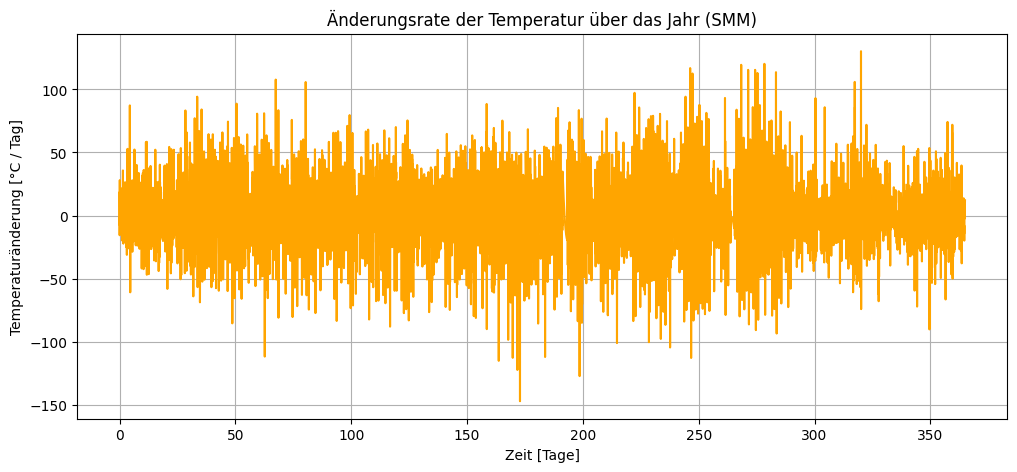

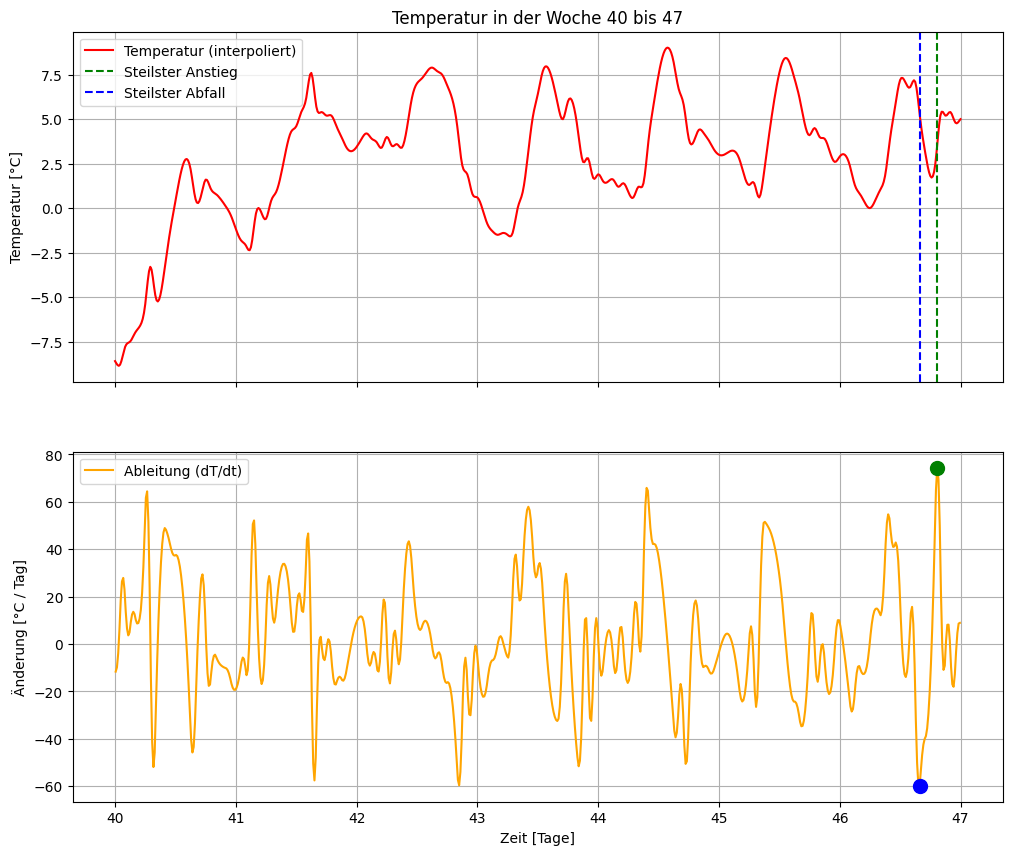

Der stärkste Temperaturanstieg war an Tag 46.81
Der stärkste Temperaturabfall war an Tag 46.66


In [35]:
# Zeitabstand zwischen zwei Punkten (in Tagen)
dt = t_interp[1] - t_interp[0]

# Numerische Ableitung: (T_nachher - T_vorher) / dt
# np.diff berechnet die Differenz zwischen aufeinanderfolgenden Elementen
temp_ableitung = np.diff(temp_interp) / dt

# Da np.diff das Array um 1 kürzt, brauchen wir eine passende Zeitachse für die Ableitung
t_ableitung = t_interp[:-1] + dt/2 

# Plot über das ganze Jahr, um Schwankungen zu finden
plt.figure(figsize=(12, 5))
plt.plot(t_ableitung, temp_ableitung, color='orange')
plt.title('Änderungsrate der Temperatur über das Jahr (SMM)')
plt.ylabel('Temperaturänderung [°C / Tag]')
plt.xlabel('Zeit [Tage]')
plt.grid()
plt.show()


# WÄHLE HIER DEINE WOCHE (Beispiel: Tag 40 bis 47)
t_start_woche = 40 
t_end_woche = 47

# Masken für die gewählte Woche
mask_woche_interp = (t_interp >= t_start_woche) & (t_interp <= t_end_woche)
mask_woche_ableitung = (t_ableitung >= t_start_woche) & (t_ableitung <= t_end_woche)

# Daten für die Woche extrahieren
t_woche = t_interp[mask_woche_interp]
temp_woche = temp_interp[mask_woche_interp]
t_abl_woche = t_ableitung[mask_woche_ableitung]
abl_woche = temp_ableitung[mask_woche_ableitung]

# Zeitpunkte der stärksten Änderung finden (Maximum und Minimum der Ableitung)
idx_max = np.argmax(abl_woche)
idx_min = np.argmin(abl_woche)

t_max_anstieg = t_abl_woche[idx_max]
t_max_fall = t_abl_woche[idx_min]

# Darstellung
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True,)

# Plot 1: Temperaturverlauf
ax1.plot(t_woche, temp_woche, 'r-', label='Temperatur (interpoliert)')
ax1.axvline(t_max_anstieg, color='green', linestyle='--', label='Steilster Anstieg')
ax1.axvline(t_max_fall, color='blue', linestyle='--', label='Steilster Abfall')
ax1.set_ylabel('Temperatur [°C]')
ax1.set_title(f'Temperatur in der Woche {t_start_woche} bis {t_end_woche}')
ax1.legend()
ax1.grid()

# Plot 2: Ableitung
ax2.plot(t_abl_woche, abl_woche, 'orange', label='Ableitung (dT/dt)')
ax2.scatter(t_max_anstieg, abl_woche[idx_max], color='green', s=100, zorder=5)
ax2.scatter(t_max_fall, abl_woche[idx_min], color='blue', s=100, zorder=5)
ax2.set_ylabel('Änderung [°C / Tag]')
ax2.set_xlabel('Zeit [Tage]')
ax2.legend()
ax2.grid()


plt.show()

print(f"Der stärkste Temperaturanstieg war an Tag {t_max_anstieg:.2f}")
print(f"Der stärkste Temperaturabfall war an Tag {t_max_fall:.2f}")

### 6. Mittelwerte berechnen

Wählt eine der Messgrössen aus und berechnet den Mittelwert über das ganze Jahr und den Mittelwert pro Monat (1 Monat = 1/12 des Jahres). Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die eigentliche Variable und die Mittelwerte zusammen grafisch dar.

Die Mittelung soll mithilfe der Integration über die Interpolationsfunktion aus Schritt 2 berechnet werden.

Bei der Integration kann es Warnungen geben, da die Interpolationsfunktionen teils stark schwanken. Es kann hilfreich sein, mit dem Parameter `limit` die Anzahl Subintervalle zu erhöhen. Probiert aus, ab wann sich das Resultat nicht mehr gross ändert.

*Empfehlungen:* 
- Implementiert dies zuerst für die Temperatur, da diese am einfachsten zu interpretieren ist. Dann könnt ihr immer noch die anderen Messgrössen betrachten.
- Beginnt mit dem Mittelwert über das ganze Jahr, dann verallgemeinert für ein beliebiges Zeitintervall und iteriert schliesslich über die Monate.

/var/folders/yf/fmfsxw9150n3zs4sklkn8rg40000gn/T/ipykernel_16024/1618043517.py:6: IntegrationWarning: The maximum number of subdivisions (1000) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, error = quad(interp_func, start, ende, limit=1000)
/var/folders/yf/fmfsxw9150n3zs4sklkn8rg40000gn/T/ipykernel_16024/1618043517.py:6: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = quad(interp_func, start, ende, limit=1000)


Jahresmittelwert (SMM): 7.68 °C


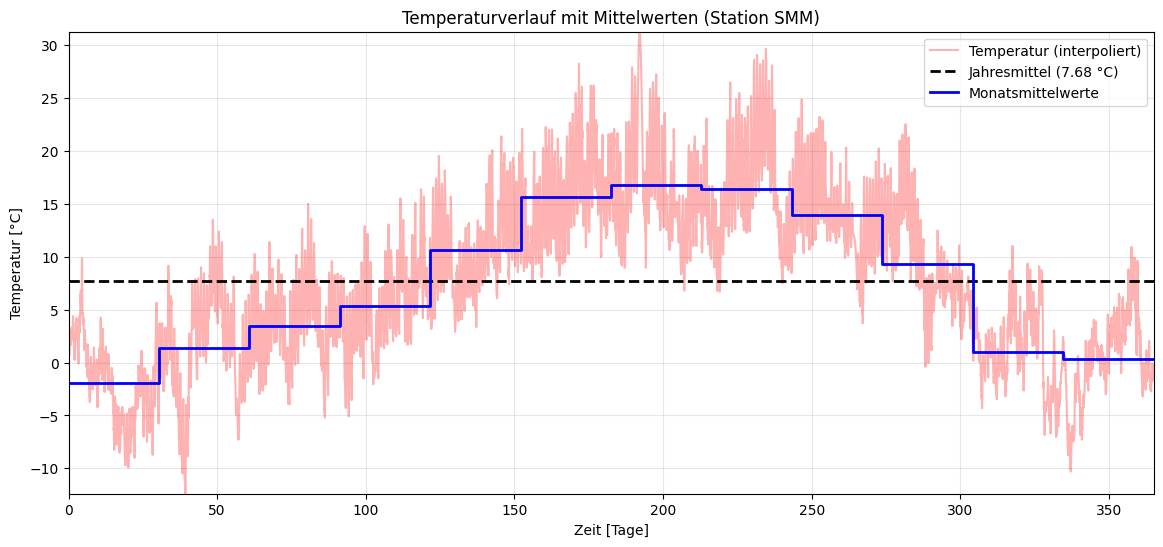

In [20]:
from scipy.integrate import quad

# Funktion zur Berechnung des Mittelwerts in einem beliebigen Intervall
def berechne_mittelwert(interp_func, start, ende):
    # Wir erhöhen das Limit von 100 auf 1000
    integral, error = quad(interp_func, start, ende, limit=1000)
    return integral / (ende - start)
# 1. Mittelwert über das ganze Jahr
t_start_jahr = time_array[0]
t_ende_jahr = time_array[-1]
mittel_jahr = berechne_mittelwert(f_temp, t_start_jahr, t_ende_jahr)

# 2. Mittelwert pro Monat (1 Monat = 1/12 des Jahres)
monate = 12
dt_monat = (t_ende_jahr - t_start_jahr) / monate
mittel_monate = []
t_monat_zentren = []

for i in range(monate):
    m_start = t_start_jahr + i * dt_monat
    m_ende = m_start + dt_monat
    m_wert = berechne_mittelwert(f_temp, m_start, m_ende)
    
    mittel_monate.append(m_wert)
    t_monat_zentren.append(m_start + dt_monat/2) # Punkt für die Darstellung in der Mitte des Monats

print(f"Jahresmittelwert (SMM): {mittel_jahr:.2f} °C")


plt.figure(figsize=(14, 6))

# Gesamter Temperaturverlauf (leicht transparent im Hintergrund)
plt.plot(t_interp, temp_interp, color='red', alpha=0.3, label='Temperatur (interpoliert)')

# Jahresmittelwert als horizontale Linie
plt.axhline(mittel_jahr, color='black', linestyle='--', linewidth=2, label=f'Jahresmittel ({mittel_jahr:.2f} °C)')

# Monatsmittelwerte als Treppenstufen oder markante Punkte
# 'where='post'' sorgt dafür, dass die Linie den ganzen Monat auf dem Level bleibt
plt.step(np.linspace(t_start_jahr, t_ende_jahr, monate+1), 
         [mittel_monate[0]] + mittel_monate, 
         color='blue', linewidth=2, label='Monatsmittelwerte')

plt.title('Temperaturverlauf mit Mittelwerten (Station SMM)')
plt.ylabel('Temperatur [°C]')
plt.xlabel('Zeit [Tage]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.margins(0)
plt.show()

### 7. Glättung (Gleitendes Mittel) bestimmen

Nehmt die gleiche Messgrösse wie in Schritt 6 und berechnet das gleitende Mittel über das ganze Jahr. Dazu soll die Faltung mit einer symmetrischen Rechteckfunktion verwendet werden. Die Fensterbreite (Breite des Rechtecks) soll ein Parameter sein, den ihr variieren könnt.

Stellt die Messgrösse und das gleitende Mittel mit Fensterbreite = 7 Tage zusammen dar. Optional könnt ihr dazu auch noch das gleitende Mittel mit Fensterbreite = 14 und/oder 28 Tage darstellen.

Entscheidet selbst, ob ihr die kontinuierliche Faltung (Integration) oder die diskrete Faltung (Matrixmultiplikation) benutzt. 

*Vorsicht:* Die kontinuierliche Faltung (Integration) ist rechenintensiv. Berechnet also zuerst das gleitende Mittel an wenigen Zeitpunkten über das ganze Jahr, z.B. 100, und erhöht dann die Anzahl Zeitpunkte vorsichtig.

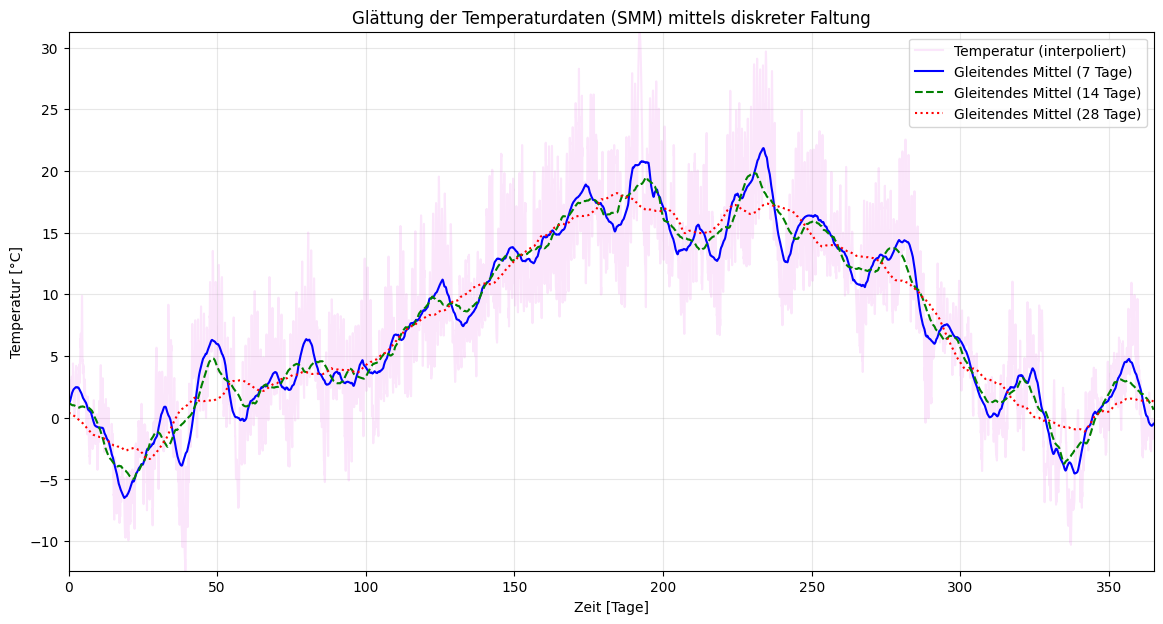

In [19]:



# Parameter definieren
# Da wir viertelstündliche Daten haben, gibt es 96 Datenpunkte pro Tag (24h * 4)
punkte_pro_tag = 24 * 4

def gleitendes_mittel_diskret(daten, tage):
    # Fensterbreite in Anzahl Datenpunkten berechnen
    window_size = int(tage * punkte_pro_tag)
    
    # Sicherstellen, dass die Fensterbreite ungerade ist (für Symmetrie)
    if window_size % 2 == 0:
        window_size += 1
        
    # Symmetrische Rechteckfunktion (Kern) erstellen
    kernel = np.ones(window_size) / window_size
    
    # Diskrete Faltung ausführen
    # 'mode=same' sorgt dafür, dass das Ergebnis die gleiche Länge wie die Originaldaten hat
    return np.convolve(daten, kernel, mode='same')

# Berechnung für 7, 14 und 28 Tage (geht jetzt blitzschnell!)
smooth_7d  = gleitendes_mittel_diskret(temp_interp, 7)
smooth_14d = gleitendes_mittel_diskret(temp_interp, 14)
smooth_28d = gleitendes_mittel_diskret(temp_interp, 28)

# Visualisierung
plt.figure(figsize=(14, 7))

# Originale interpolierte Daten (leicht transparent)
plt.plot(t_interp, temp_interp, color='violet', alpha=0.2, label='Temperatur (interpoliert)')

# Die geglätteten Kurven (jetzt auf der vollen Zeitachse t_interp!)
plt.plot(t_interp, smooth_7d,  'b-',  label='Gleitendes Mittel (7 Tage)')
plt.plot(t_interp, smooth_14d, 'g--', label='Gleitendes Mittel (14 Tage)')
plt.plot(t_interp, smooth_28d, 'r:',  label='Gleitendes Mittel (28 Tage)')

plt.title('Glättung der Temperaturdaten (SMM) mittels diskreter Faltung')
plt.ylabel('Temperatur [°C]')
plt.xlabel('Zeit [Tage]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.margins(0)
plt.show()

### Zusammenfassung

### Reflexion

Mitglied 1:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.


Mitglied 2:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.

Mitglied 3:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.